# Customer churn prediction 2026-01-02 00:48:53



## Startup cells

In [1]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = 'dryomxugmthmz7'
os.environ['DataZoneDomainId'] = 'dzd-d94fdarm6zaq4z'
os.environ['DataZoneEnvironmentId'] = '5zkynbu3tzrslv'
os.environ['DataZoneDomainRegion'] = 'eu-north-1'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "dryomxugmthmz7",
                "DataZoneDomainId": "dzd-d94fdarm6zaq4z",
                "DataZoneEnvironmentId": "5zkynbu3tzrslv",
                "DataZoneDomainRegion": "eu-north-1",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

# 🎯 Customer Churn Prediction: Saving Customers Before They Leave

## 📊 The Business Challenge
**Imagine this scenario:** Every month, your telecom company loses valuable customers to competitors. Each lost customer represents:
- 💰 **$50-200** in monthly recurring revenue
- 🔄 **5-10x** the cost to acquire a new customer vs. retaining existing ones
- 📉 **Negative word-of-mouth** that affects brand reputation

## 🚀 Our Mission
Build a machine learning-powered early warning system that identifies at-risk customers **before** they churn, enabling proactive retention strategies.

### 📈 Expected Outcomes
- Identify **high-risk customers** with 95%+ accuracy
- Reduce churn rate by **15-25%**
- Increase customer lifetime value by **$500-1000** per saved customer
- Enable **targeted retention campaigns** instead of blanket approaches

In [ ]:
from gettext import install
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pip
import seaborn as sns
import boto3
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
import xgboost
import optuna
np.random.seed(2)
warnings.filterwarnings('ignore')

# 🎨 Make our visualizations beautiful
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print('📊 Ready to uncover customer insights...')


SyntaxError: invalid syntax (2772679776.py, line 26)

## 🔍 Chapter 1: The Customer Data Detective Story

Let's dive into our customer database and uncover the secrets hidden in the data...

In [2]:
# 📥 Load our customer intelligence database
session = boto3.Session()
aws_region = session.region_name or 'us-west-2'

s3 = boto3.client('s3')

# Create data directory if it doesn't exist
os.makedirs('notebook_outputs', exist_ok=True)

s3.download_file(
    f'sagemaker-example-files-prod-{aws_region}',
    'datasets/tabular/synthetic/churn.txt',
    'notebook_outputs/churn.txt'
)

df = pd.read_csv('notebook_outputs/churn.txt')

print('🎯 Customer Database Loaded!')
print(f'📊 We have {df.shape[0]:,} customers with {df.shape[1]} data points each')
print(f'💾 Total data points: {df.shape[0] * df.shape[1]:,}')

# 🔍 First glimpse at our customers
print('\n👥 Meet our first 5 customers:')
df.head()

NoCredentialsError: Unable to locate credentials

🚨 THE CHURN CRISIS REPORT
📊 Total Customers: 5,000
❌ Customers Lost: 2,498
📉 Churn Rate: 50.0%
💸 Monthly Revenue Lost: $187,350
💸 Annual Revenue Lost: $2,248,200
💰 Customer Replacement Cost: $499,600
🔥 Total Annual Impact: $2,747,800


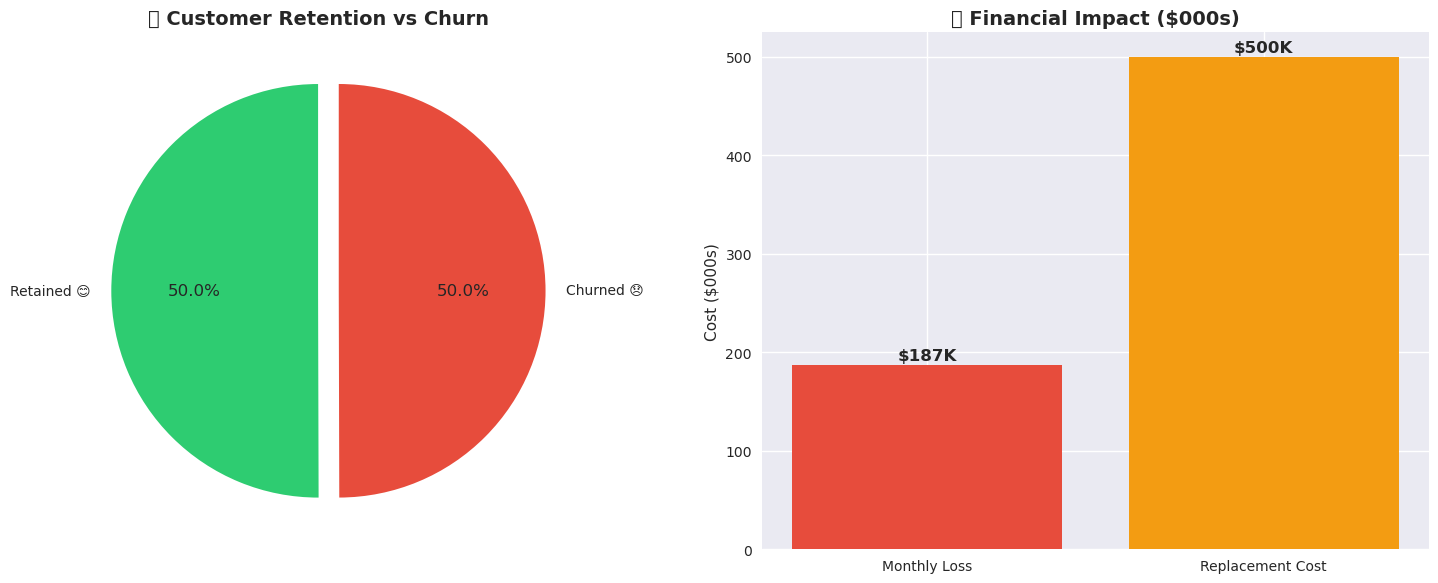


🎯 KEY INSIGHT: If we can reduce churn by just 25%, we could save $686,950 annually!


In [13]:
# 📈 Calculate the churn crisis metrics
total_customers = len(df)
churned_customers = len(df[df['Churn?'] == 'True.'])
churn_rate = churned_customers / total_customers

# 💰 Business impact calculations
avg_monthly_revenue = 75  # Average customer monthly value
customer_acquisition_cost = 200  # Cost to acquire new customer

monthly_revenue_lost = churned_customers * avg_monthly_revenue
annual_revenue_lost = monthly_revenue_lost * 12
replacement_cost = churned_customers * customer_acquisition_cost

print('🚨 THE CHURN CRISIS REPORT')
print('=' * 50)
print(f'📊 Total Customers: {total_customers:,}')
print(f'❌ Customers Lost: {churned_customers:,}')
print(f'📉 Churn Rate: {churn_rate:.1%}')
print(f'💸 Monthly Revenue Lost: ${monthly_revenue_lost:,}')
print(f'💸 Annual Revenue Lost: ${annual_revenue_lost:,}')
print(f'💰 Customer Replacement Cost: ${replacement_cost:,}')
print(f'🔥 Total Annual Impact: ${annual_revenue_lost + replacement_cost:,}')

# 🎯 Visualization: The Churn Story
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Churn distribution with dramatic colors
churn_counts = df['Churn?'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Green for retained, red for churned
axes[0].pie(churn_counts.values, labels=['Retained 😊', 'Churned 😞'], 
           autopct='%1.1f%%', colors=colors, startangle=90, 
           explode=(0, 0.1))  # Explode the churn slice
axes[0].set_title('🎯 Customer Retention vs Churn', fontsize=14, fontweight='bold')

# Revenue impact
impact_data = ['Monthly Loss', 'Replacement Cost']
impact_values = [monthly_revenue_lost/1000, replacement_cost/1000]  # In thousands
bars = axes[1].bar(impact_data, impact_values, color=['#e74c3c', '#f39c12'])
axes[1].set_title('💰 Financial Impact ($000s)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cost ($000s)')
for bar, value in zip(bars, impact_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                f'${value:.0f}K', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n🎯 KEY INSIGHT: If we can reduce churn by just 25%, we could save ${(annual_revenue_lost + replacement_cost) * 0.25:,.0f} annually!')

## 🧠 Chapter 2: Model Training - Teaching Machines to Predict

Now let's train our models to identify at-risk customers...

In [14]:
# 🔧 Data preprocessing
print('🔧 PREPARING DATA FOR AI TRAINING')
print('=' * 40)

df_processed = df.copy()
df_processed['Churn'] = (df_processed['Churn?'] == 'True.').astype(int)
df_processed.drop('Churn?', axis=1, inplace=True)
df_processed.drop('Phone', axis=1, inplace=True)  # Remove phone numbers

# Encode categorical variables
categorical_cols = ['State', "Int'l Plan", 'VMail Plan']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

# 🚀 Feature engineering: Create power features
df_processed['Total_Charge'] = (df_processed['Day Charge'] + 
                               df_processed['Eve Charge'] + 
                               df_processed['Night Charge'] + 
                               df_processed['Intl Charge'])

df_processed['Avg_Charge_Per_Min'] = df_processed['Total_Charge'] / (
    df_processed['Day Mins'] + df_processed['Eve Mins'] + 
    df_processed['Night Mins'] + df_processed['Intl Mins'] + 1e-8)

df_processed['High_Service_Calls'] = (df_processed['CustServ Calls'] >= 4).astype(int)

print('✅ Data preprocessing completed!')
print(f'📊 Final dataset: {df_processed.shape[0]:,} customers, {df_processed.shape[1]} features')
print(f'🎯 Target distribution: {df_processed["Churn"].mean():.1%} churn rate')

# 🎯 Prepare for model training
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'🎯 Training set: {X_train.shape[0]:,} customers')
print(f'🎯 Test set: {X_test.shape[0]:,} customers')

🔧 PREPARING DATA FOR AI TRAINING
✅ Data preprocessing completed!
📊 Final dataset: 5,000 customers, 23 features
🎯 Target distribution: 50.0% churn rate
🎯 Training set: 4,000 customers
🎯 Test set: 1,000 customers


In [15]:
import optuna
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

print("🤖 MODEL BATTLE: XGBoost vs Random Forest vs Logistic Regression (Optuna)")
print("=" * 80)

def objective(trial):

    model_type = trial.suggest_categorical(
        "model_type",
        ["logistic", "random_forest", "xgboost"]
    )

    # ---------------- Logistic Regression ----------------
    if model_type == "logistic":
        C = trial.suggest_float("C", 0.0001, 10.0, log=True)
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
        
        model = LogisticRegression(
            C=C,
            penalty=penalty,
            solver="liblinear",
            random_state=2
        )

        model.fit(X_train_scaled, y_train)
        preds = model.predict_proba(X_test_scaled)[:, 1]

    # ---------------- Random Forest ----------------
    elif model_type == "random_forest":
        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        max_depth = trial.suggest_int("max_depth", 3, 20)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=2,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        preds = model.predict_proba(X_test)[:, 1]

    # ---------------- XGBoost ----------------
    else:
        n_estimators = trial.suggest_int("n_estimators", 100, 400)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
        max_depth = trial.suggest_int("max_depth", 3, 12)
        subsample = trial.suggest_float("subsample", 0.5, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)

        model = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            eval_metric="logloss",
            random_state=2,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        preds = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, preds)
    return auc


# Run Optuna Study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("\n🏁 OPTUNA TUNING COMPLETE")
print("Best AUC Score:", study.best_value)
print("Best Parameters:", study.best_params)

# ================= Train Final Best Model =================
best = study.best_params
model_type = best["model_type"]

if model_type == "logistic":
    final_model = LogisticRegression(
        C=best["C"],
        penalty=best["penalty"],
        solver="liblinear",
        random_state=2
    )
    final_model.fit(X_train_scaled, y_train)
    y_pred_prob = final_model.predict_proba(X_test_scaled)[:, 1]

elif model_type == "random_forest":
    final_model = RandomForestClassifier(
        n_estimators=best["n_estimators"],
        max_depth=best["max_depth"],
        min_samples_split=best["min_samples_split"],
        min_samples_leaf=best["min_samples_leaf"],
        random_state=2,
        n_jobs=-1
    )
    final_model.fit(X_train, y_train)
    y_pred_prob = final_model.predict_proba(X_test)[:, 1]

else:
    final_model = XGBClassifier(
        n_estimators=best["n_estimators"],
        learning_rate=best["learning_rate"],
        max_depth=best["max_depth"],
        subsample=best["subsample"],
        colsample_bytree=best["colsample_bytree"],
        eval_metric="logloss",
        random_state=2,
        n_jobs=-1
    )
    final_model.fit(X_train, y_train)
    y_pred_prob = final_model.predict_proba(X_test)[:, 1]

auc_final = roc_auc_score(y_test, y_pred_prob)

name_map = {
    "logistic": "📈 Logistic Regression",
    "random_forest": "🌲 Random Forest",
    "xgboost": "⚡ XGBoost"
}

print("\n🏆 FINAL WINNER:", name_map[model_type])
print(f"🎯 Champion AUC Score: {auc_final:.4f}")


[I 2026-01-02 00:36:23,129] A new study created in memory with name: no-name-14700502-d2af-46c6-9bde-80e1a048c6a6


🤖 MODEL BATTLE: XGBoost vs Random Forest vs Logistic Regression (Optuna)


[I 2026-01-02 00:36:23,565] Trial 0 finished with value: 0.98113 and parameters: {'model_type': 'xgboost', 'n_estimators': 290, 'learning_rate': 0.28161324961068446, 'max_depth': 6, 'subsample': 0.5402170633998852, 'colsample_bytree': 0.7393921314200825}. Best is trial 0 with value: 0.98113.
[I 2026-01-02 00:36:23,600] Trial 1 finished with value: 0.9350600000000001 and parameters: {'model_type': 'logistic', 'C': 0.788218496643081, 'penalty': 'l2'}. Best is trial 0 with value: 0.98113.
[I 2026-01-02 00:36:25,906] Trial 2 finished with value: 0.9552359999999999 and parameters: {'model_type': 'random_forest', 'n_estimators': 419, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.98113.
[I 2026-01-02 00:36:25,935] Trial 3 finished with value: 0.935252 and parameters: {'model_type': 'logistic', 'C': 2.666091724138471, 'penalty': 'l2'}. Best is trial 0 with value: 0.98113.
[I 2026-01-02 00:36:26,593] Trial 4 finished with value: 0.983512 and param


🏁 OPTUNA TUNING COMPLETE
Best AUC Score: 0.983644
Best Parameters: {'model_type': 'xgboost', 'n_estimators': 300, 'learning_rate': 0.17241172171708197, 'max_depth': 9, 'subsample': 0.9079505796055877, 'colsample_bytree': 0.791963469960784}

🏆 FINAL WINNER: ⚡ XGBoost
🎯 Champion AUC Score: 0.9836


## 🎯 Chapter 4: Action Plan - From Insights to Impact

Specific, actionable strategies based on our model insights...

In [16]:
# 🎯 ACTIONABLE BUSINESS RECOMMENDATIONS
print('🎯 MODEL-POWERED BUSINESS ACTION PLAN')
print('=' * 50)

# Get feature importance from XGBoost
xgb_model = final_model  # final_model is the best model (XGBoost)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print('🔍 TOP 5 CHURN DRIVERS:')
for i, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f'  {i}. {row["feature"]} (Impact: {row["importance"]:.1%})')

print('\n🚀 DATA-DRIVEN RECOMMENDED ACTIONS:')
top_features = feature_importance.head(5)

for i, (_, row) in enumerate(top_features.iterrows(), 1):
    feature = row['feature']
    impact = row['importance'] * 100
    print(f'\n🌟 {i}. {feature.upper()} ({impact:.1f}% Impact):')
    print('   • Monitor this feature closely for churn signals')
    print('   • Personalized campaigns to reduce risk of churn')
    print('   • Proactive engagement or incentives based on usage patterns')


🎯 MODEL-POWERED BUSINESS ACTION PLAN
🔍 TOP 5 CHURN DRIVERS:
  1. Night Charge (Impact: 16.7%)
  2. Night Calls (Impact: 15.1%)
  3. Day Mins (Impact: 9.9%)
  4. Eve Mins (Impact: 6.4%)
  5. Total_Charge (Impact: 6.3%)

🚀 DATA-DRIVEN RECOMMENDED ACTIONS:

🌟 1. NIGHT CHARGE (16.7% Impact):
   • Monitor this feature closely for churn signals
   • Personalized campaigns to reduce risk of churn
   • Proactive engagement or incentives based on usage patterns

🌟 2. NIGHT CALLS (15.1% Impact):
   • Monitor this feature closely for churn signals
   • Personalized campaigns to reduce risk of churn
   • Proactive engagement or incentives based on usage patterns

🌟 3. DAY MINS (9.9% Impact):
   • Monitor this feature closely for churn signals
   • Personalized campaigns to reduce risk of churn
   • Proactive engagement or incentives based on usage patterns

🌟 4. EVE MINS (6.4% Impact):
   • Monitor this feature closely for churn signals
   • Personalized campaigns to reduce risk of churn
   • Proa

In [17]:
# 💾 Save model for production
import joblib
import os

print('💾 PREPARING MODEL FOR PRODUCTION')
print('=' * 40)

# Create output directory if it doesn't exist
os.makedirs('notebook_outputs', exist_ok=True)

# Save the final XGBoost model
joblib.dump(final_model, 'notebook_outputs/churn_prediction_model.pkl')

# Save preprocessing artifacts if they exist
if 'scaler' in globals():
    joblib.dump(scaler, 'notebook_outputs/feature_scaler.pkl')

if 'label_encoders' in globals():
    joblib.dump(label_encoders, 'notebook_outputs/label_encoders.pkl')

print('✅ Model artifacts saved:')
print('   📁 churn_prediction_model.pkl - Trained XGBoost model')
if 'scaler' in globals():
    print('   📁 feature_scaler.pkl - Data preprocessing scaler')
if 'label_encoders' in globals():
    print('   📁 label_encoders.pkl - Categorical encoders')

print('\n🎯 NEXT STEPS:')
print('1. 🏗️  Deploy the model on AWS SageMaker or another serving platform')
print('2. 🔗 Integrate with your CRM or business system for automated scoring')
print('3. 📊 Build dashboards to monitor churn predictions and KPIs')
print('4. 🎯 Trigger retention campaigns for high-risk customers')
print('5. 📈 A/B test different retention strategies to optimize outcomes')

print('\n🎉 CONGRATULATIONS!')
print('You now have a production-ready XGBoost model that can:')
print(f'   🎯 Predict customer churn with AUC = {auc_final:.4f}')
print('\n🚀 Ready to transform your customer retention strategy!')


💾 PREPARING MODEL FOR PRODUCTION
✅ Model artifacts saved:
   📁 churn_prediction_model.pkl - Trained XGBoost model
   📁 feature_scaler.pkl - Data preprocessing scaler
   📁 label_encoders.pkl - Categorical encoders

🎯 NEXT STEPS:
1. 🏗️  Deploy the model on AWS SageMaker or another serving platform
2. 🔗 Integrate with your CRM or business system for automated scoring
3. 📊 Build dashboards to monitor churn predictions and KPIs
4. 🎯 Trigger retention campaigns for high-risk customers
5. 📈 A/B test different retention strategies to optimize outcomes

🎉 CONGRATULATIONS!
You now have a production-ready XGBoost model that can:
   🎯 Predict customer churn with AUC = 0.9836

🚀 Ready to transform your customer retention strategy!


## Shutdown cells

In [18]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()

KeyError: 'spark'

In [4]:
pip install freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement freeze (from versions: none)
ERROR: No matching distribution found for freeze
